In [43]:
import pandas as pd 
import numpy as np 
import  matplotlib.pyplot as plt 
import seaborn as sns 
import warnings ## warnings is a built-in module used to handle warning messages ## 
warnings.filterwarnings('ignore')# “Ignore ALL warnings. Don’t show them.”
data = pd.read_csv("data/stud.csv")

In [44]:
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [46]:
## number of unique values of each columns 

data.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [47]:
# Exploring the data
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [48]:
print("Categories in Gender is :" ,end='')
print(data['gender'].unique())
print("Categories in race_ethnicity is :" ,end='')
print(data['race_ethnicity'].unique())
print("Categories in parental_level_of_education is :" ,end='')
print(data['parental_level_of_education'].unique())
print("Categories in lunch is :" ,end='')
print(data['lunch'].unique())
print("Categories in test_preparation_course is :" ,end='')
print(data['test_preparation_course'].unique())



Categories in Gender is :['female' 'male']
Categories in race_ethnicity is :['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental_level_of_education is :["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch is :['standard' 'free/reduced']
Categories in test_preparation_course is :['none' 'completed']


In [49]:
num_features = data.select_dtypes(exclude='object').columns
cat_features = data.select_dtypes(include="object").columns
print(cat_features)
print(num_features)


Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')
Index(['math_score', 'reading_score', 'writing_score'], dtype='object')


In [50]:
## adding a columns of total score and average score 
data['Total_score'] = data['math_score']+data['writing_score'] + data['reading_score']
data['average_score'] = data['Total_score']/3

In [51]:
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [52]:
maths_score_full = data[data['math_score'] ==100]['average_score'].count()
writing_score_full = data[data['writing_score'] == 100]['average_score'].count()
reading_score_full = data[data['reading_score'] == 100]['average_score'].count()
print(f"Number of students gain full marks in maths  :{maths_score_full}")
print(f"Number of students gain full marks in reading  :{reading_score_full}")
print(f"Number of students gain full marks in writing   :{writing_score_full}")

Number of students gain full marks in maths  :7
Number of students gain full marks in reading  :17
Number of students gain full marks in writing   :14


In [53]:
reading_less_20 = data[data['reading_score'] <= 20]['average_score'].count()
writing_less_20 = data[data['writing_score'] <= 20]['average_score'].count()
math_less_20 = data[data['math_score'] <= 20]['average_score'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


<Axes: xlabel='average_score', ylabel='Count'>

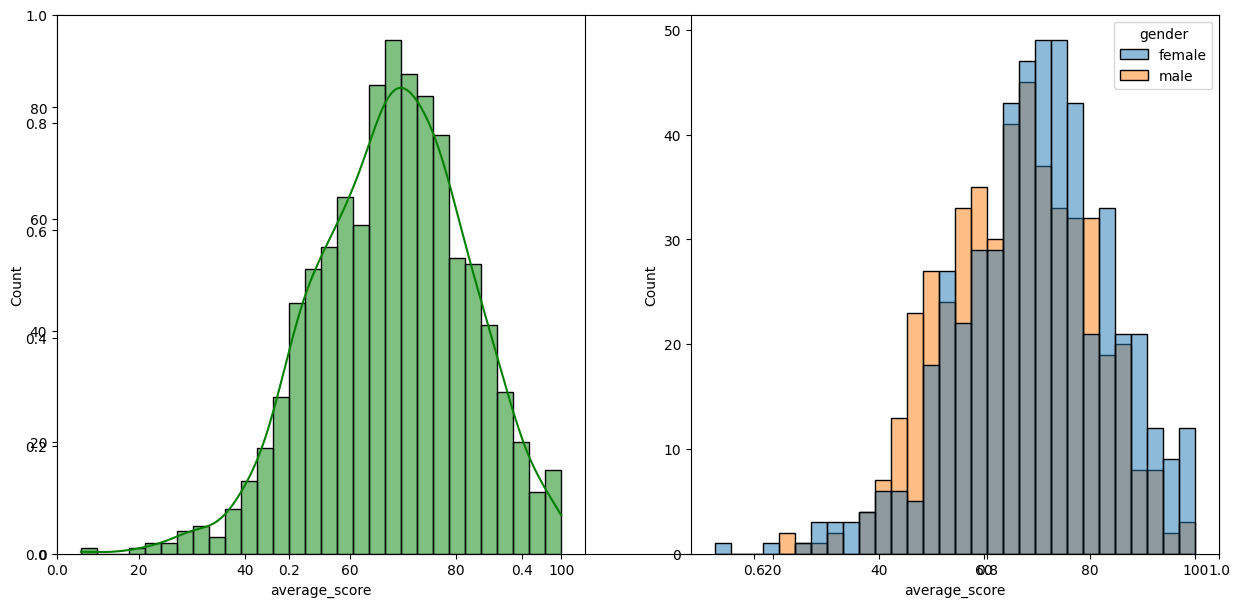

In [63]:
## Hist and kd plot 
# fig , ax = plt.Subplot(1,2,figsize =(10,4))
fig, ax = plt.subplots(figsize=(15, 7))
plt.subplot(1 , 2 , 1)
sns.histplot(data=data , x='average_score' , bins=30 , kde=True , color='g')
plt.subplot(1 ,2 ,2)
sns.histplot(data=data , x='average_score', bins=30 , hue='gender' )

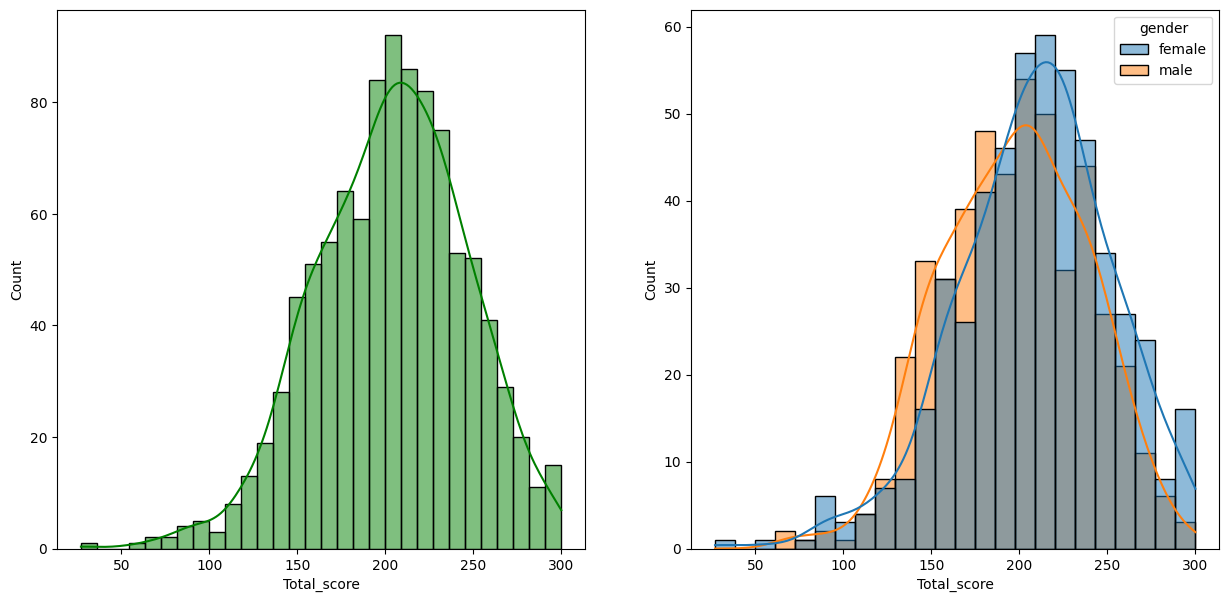

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=data,x='Total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=data,x='Total_score',kde=True,hue='gender')
plt.show()